In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=10)

cifar_train = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


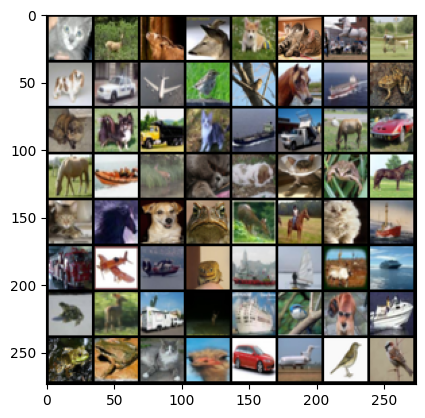

In [4]:
def random_grid(imgs, sz: int):
    samples_ix = torch.randint(low=0, high=len(imgs) - 1, size=(sz,))
    samples = imgs[samples_ix]
    grid = tu.make_grid(samples)
    return grid.permute(1, 2, 0)

tmps = torch.from_numpy(cifar_train.data)
tmps = random_grid(tmps.permute(0, 3, 1, 2), 64)
plt.imshow(tmps)

In [5]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [6]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = x.reshape(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        x = F.softmax(x, dim=-1)
        return x

class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (16x16)
        self.lin1 = nn.Linear(ch*2 * 16 * 16, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*2 * 16 * 16)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [7]:
from torchinfo import summary
testmodel = MyCnn(out_sz=10, ch=16)
# testmodel = MyNn(3 * 32 * 32, 10, hidden_sz=512)
test = cifar_train[0][0].float()
target = cifar_train[0][1].float()
print(target, testmodel(test))
summary(testmodel, (1, 3, 32, 32))

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]) tensor([[7.6818e-03, 2.5124e-07, 5.0019e-03, 2.9092e-07, 6.5191e-01, 3.2192e-01,
         1.2509e-02, 9.7683e-04, 1.0233e-06, 4.3508e-07]],
       grad_fn=<SoftmaxBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 32, 32]           448
├─Conv2d: 1-2                            [1, 32, 32, 32]           4,640
├─Linear: 1-3                            [1, 128]                  1,048,704
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 1,055,082
Trainable params: 1,055,082
Non-trainable params: 0
Total mult-adds (M): 6.26
Input size (MB): 0.01
Forward/backward pass size (MB): 0.39
Params size (MB): 4.22
Estimated Total Size (MB): 4.63

2.236032724380493
2.133030652999878
2.0824639797210693
2.0635929107666016
2.084320545196533
2.033796548843384
2.0222630500793457
2.0241127014160156
2.025620937347412
2.0299110412597656
2.0187084674835205
1.9939123392105103
1.9974082708358765
1.9752203226089478
2.0029349327087402
1.974706768989563
1.9687745571136475
1.9638665914535522
1.9673303365707397
1.9545817375183105
1.9652889966964722
1.9499106407165527
1.9444166421890259
1.948838472366333
1.950919270515442
1.9423084259033203
1.9285885095596313
1.9293714761734009
1.9256236553192139
1.9243965148925781
CPU times: user 5min 31s, sys: 10.7 s, total: 5min 42s
Wall time: 41 s


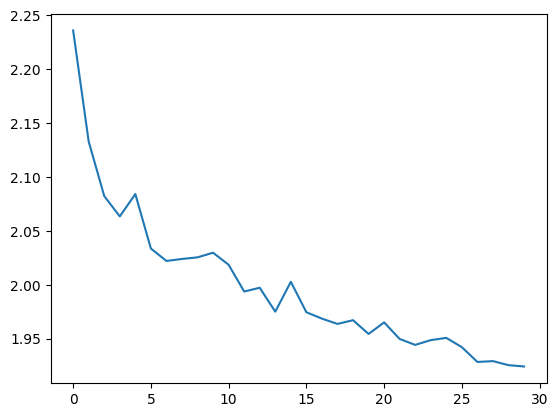

In [8]:
%%time
device='cuda'
# model = MyNn(3 * 32 * 32, 11, hidden_sz=512).to(device)
model = MyCnn(out_sz=10, ch=16).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()
epochs = 30

loss_plot = []
for epoch in range(epochs):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 10))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 10))
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [9]:
total = len(cifar_eval)
correct = 0
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

52.62% correct
